In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [3]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

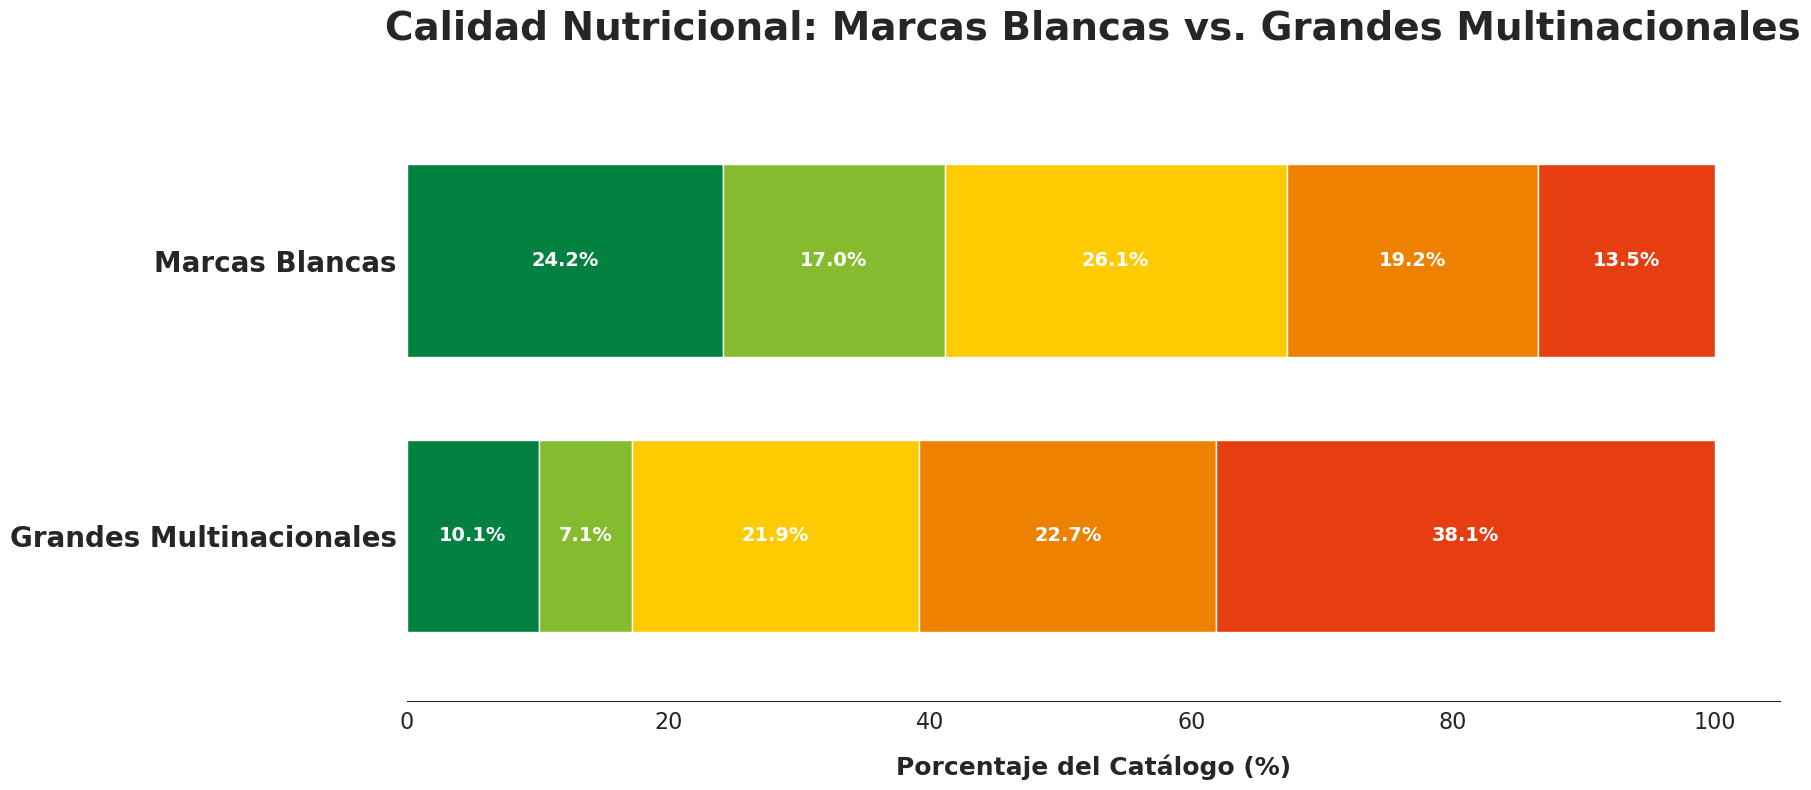

In [4]:
# --- COMPARATIVA: MARCAS BLANCAS VS MULTINACIONALES ---

# 1. Definición de Grupos (Listas optimizadas)
marcas_blancas = [
    'hacendado', 'mercadona', 'deliplus', 'compy', 'bosque verde', 'entrepinares', 
    'lidl', 'alesto', 'milbona', 'fin carré', 'sondey', 'freshona', 'crownfield', 
    'carrefour', 'u bio', 'paturages', 'nos regions ont du talent', 'bio village', 
    'marque repère', 'aldi', 'harvest morn', 'village bakery', 'tesco', 'auchan', 'intermarche'
]

grandes_multinacionales = [
    'nestle', 'nescafe', 'unilever', 'hellmann', 'knorr', 'mondelez', 'lu', 'milka', 
    'danone', 'activia', 'ferrero', 'nutella', 'pepsico', 'lays', 'coca-cola', 
    'kellogg', 'pringles', 'heinz', 'mars', 'dr. oetker'
]

# 2. Clasificación Robusta
foods['brands_clean'] = foods['brands'].fillna('').astype(str).str.lower()

def clasificar_grupo(brand_str):
    if any(mb in brand_str for mb in marcas_blancas):
        return 'Marcas Blancas'
    if any(multi in brand_str for multi in grandes_multinacionales):
        return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo'] = foods['brands_clean'].apply(clasificar_grupo)

# 3. Preparación de Datos
df_plot = foods[
    foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']) & 
    foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales'])
].copy()

# Cálculo de porcentajes
dist = df_plot.groupby(['grupo', 'nutriscore_grade']).size().unstack(fill_value=0)
pct = dist.div(dist.sum(axis=1), axis=0) * 100
order = ['a', 'b', 'c', 'd', 'e']
pct = pct[order]

# 4. Visualización Estilo Tesis
plt.figure(figsize=(18, 8))
sns.set_style("white")

colors_ns = ['#038141', '#85BB2F', '#FECB02', '#EE8100', '#E63E11'] # Paleta oficial NS

# Dibujamos barras horizontales apiladas
ax = pct.plot(kind='barh', stacked=True, color=colors_ns, ax=plt.gca(), edgecolor='white', width=0.7)

# 5. Etiquetas de Porcentaje dentro de las barras
for p in ax.patches:
    width = p.get_width()
    if width > 5: # Solo ponemos el texto si el segmento es suficientemente grande
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{width:.1f}%', (x, y), ha='center', va='center', 
                    fontsize=14, fontweight='bold', color='white')

# Estética y Fuentes
plt.title("Calidad Nutricional: Marcas Blancas vs. Grandes Multinacionales", 
          fontsize=28, fontweight='bold', pad=40)
plt.xlabel("Porcentaje del Catálogo (%)", fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel("", fontsize=1) # Ocultamos ylabel para dar aire a los nombres de grupo

plt.xticks(fontsize=16)
plt.yticks(fontsize=20, fontweight='bold')

# Leyenda superior personalizada
plt.legend(labels=['Nutri-Score A', 'Nutri-Score B', 'Nutri-Score C', 'Nutri-Score D', 'Nutri-Score E'],
           loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, 
           fontsize=14, frameon=True, shadow=True)

sns.despine(left=True)
plt.tight_layout()
plt.gca().get_legend().remove()
plt.savefig('../images/03_h03/3.1_Nutri-Mb-Mn.png', bbox_inches='tight', dpi=300)
plt.show()



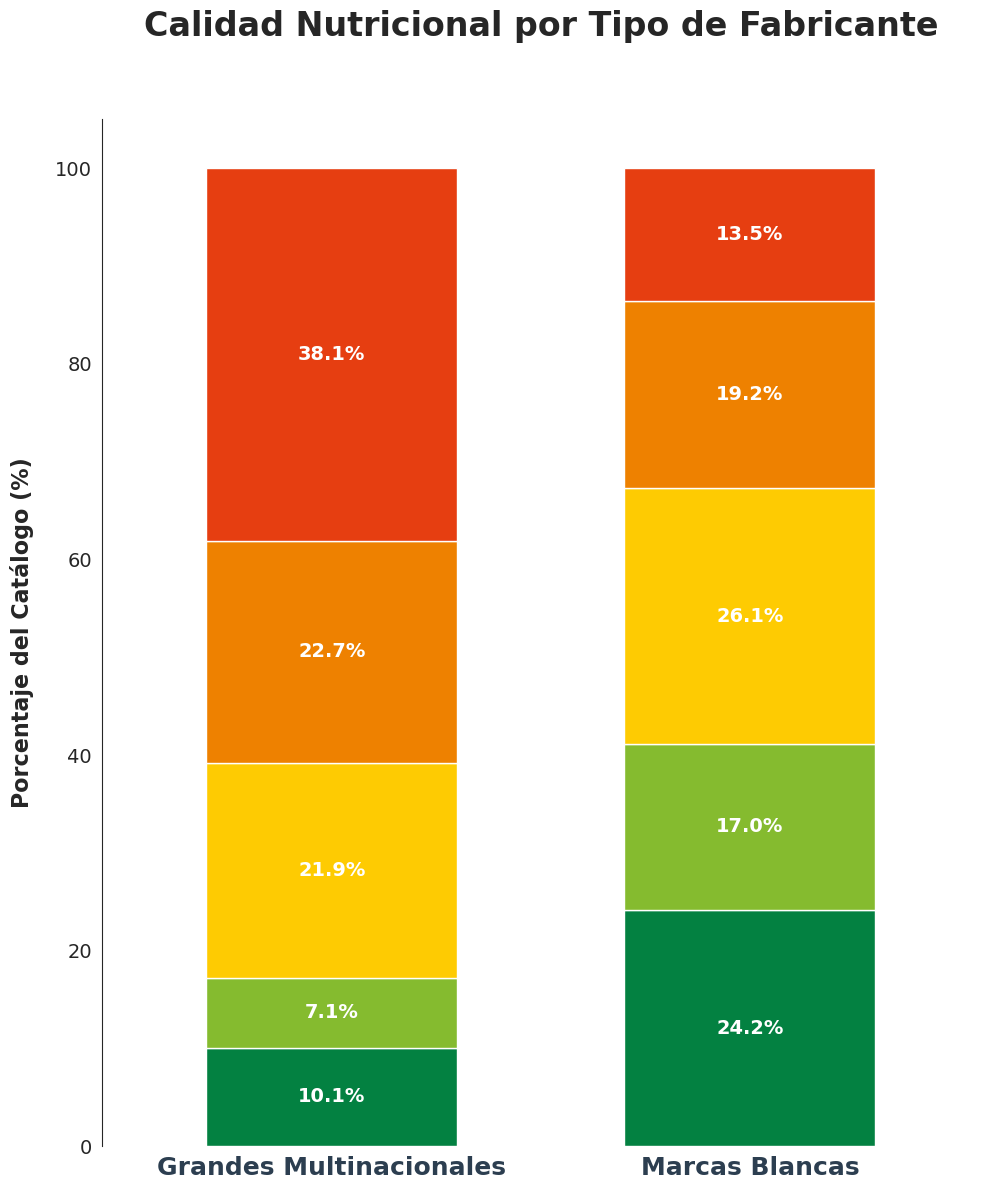

In [17]:
# --- COMPARATIVA VERTICAL: MARCAS BLANCAS VS MULTINACIONALES ---

# 1. Preparación de Datos (Igual a tu lógica)
# ... (asumiendo que pct ya está calculado como en tu código) ...
pct_v = pct.reindex(['Grandes Multinacionales', 'Marcas Blancas']) # Ordenamos

# 2. Visualización Vertical
plt.figure(figsize=(10, 12)) # Más alto que ancho para la versión vertical
sns.set_style("white")
colors_ns = ['#038141', '#85BB2F', '#FECB02', '#EE8100', '#E63E11']

# Cambiamos barh por bar
ax = pct_v.plot(kind='bar', stacked=True, color=colors_ns, ax=plt.gca(), 
                edgecolor='white', width=0.6)

# 3. Anotaciones de Porcentaje (Ajustadas a vertical)
for p in ax.patches:
    height = p.get_height()
    if height > 4: # Solo si el segmento es visible
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height / 2
        ax.annotate(f'{height:.1f}%', (x, y), ha='center', va='center', 
                    fontsize=14, fontweight='bold', color='white')

# 4. Estética de Tesis
plt.title("Calidad Nutricional por Tipo de Fabricante", 
          fontsize=24, fontweight='bold', pad=60)

# Ejes
plt.ylabel("Porcentaje del Catálogo (%)", fontsize=16, fontweight='bold', labelpad=15)
plt.xlabel("", fontsize=1)
plt.xticks(rotation=0, fontsize=18, fontweight='bold', color='#2c3e50')
plt.yticks(fontsize=14)

# Leyenda compacta en la parte superior
plt.legend(labels=['A', 'B', 'C', 'D', 'E'],
           title="Nutri-Score", title_fontsize=12,
           loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, 
           fontsize=13, frameon=True, shadow=True)
plt.gca().get_legend().remove()
sns.despine(bottom=True) # Quitamos la línea de abajo para un look más moderno
plt.tight_layout()

plt.savefig('../images/03_h03/3.1_Nutri-Mb-Mn_Vertical.png', bbox_inches='tight', dpi=300)
plt.show()

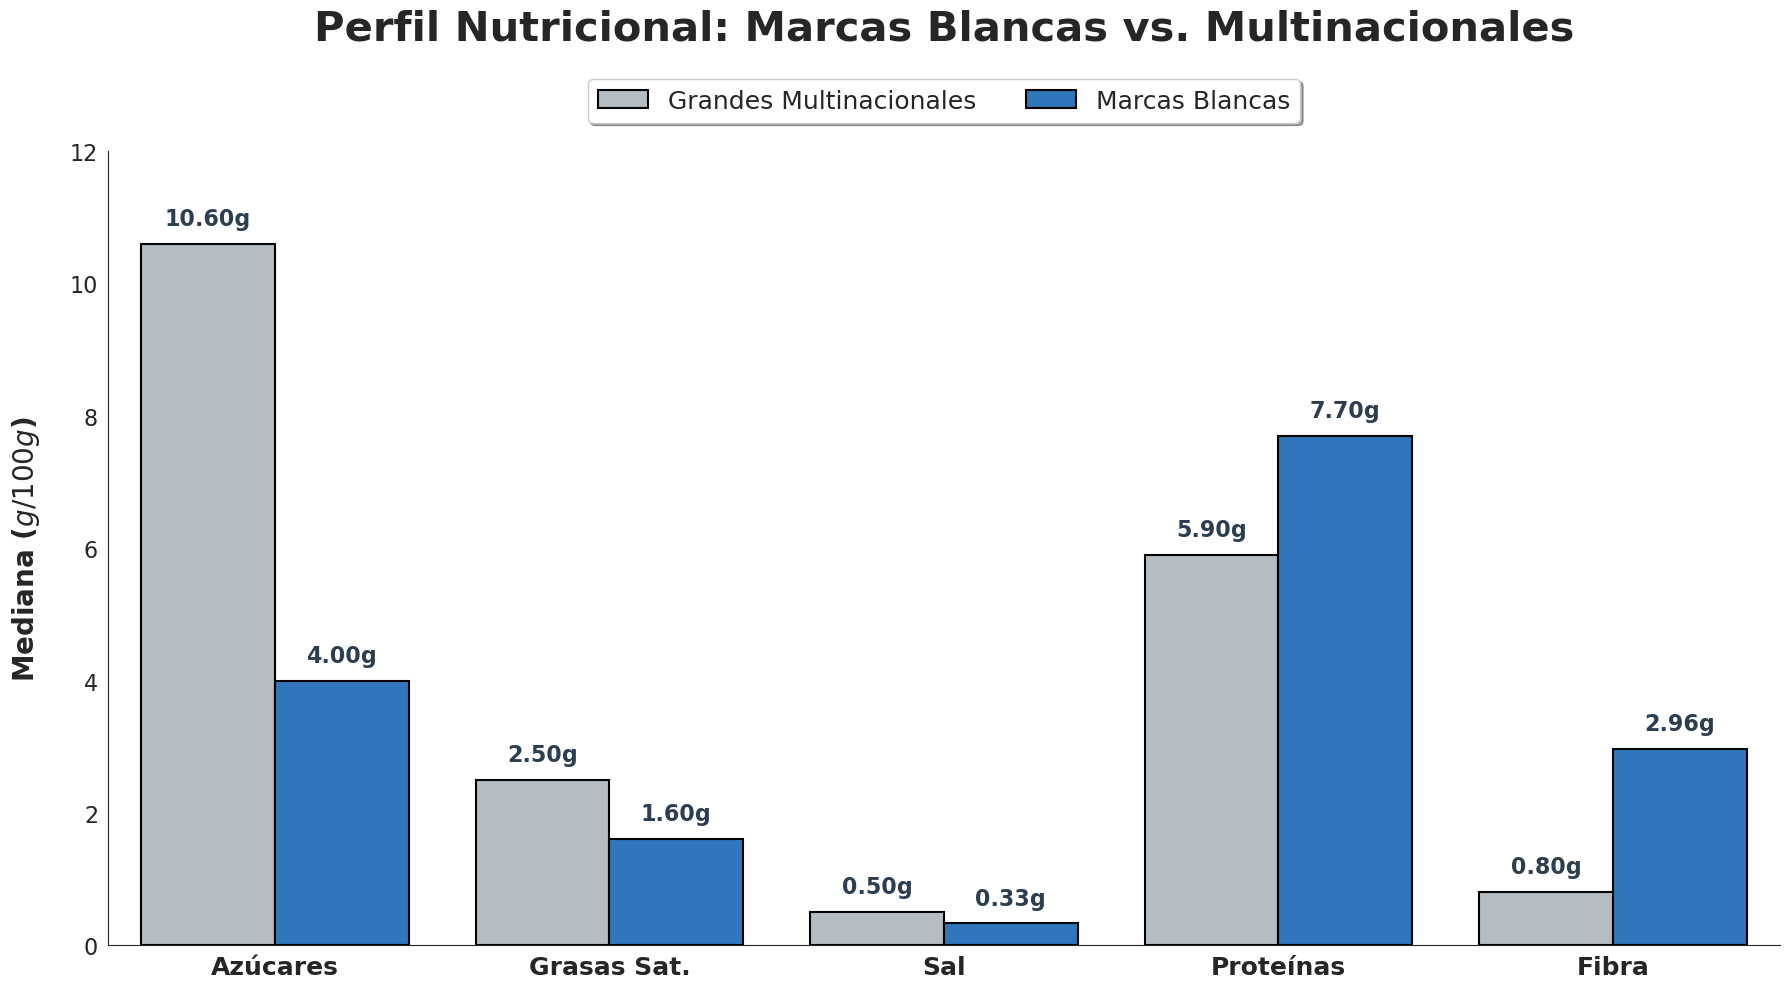

In [16]:
# --- PERFIL NUTRICIONAL COMPARATIVO (MEDIANA, SIN DESVIACIÓN, EJE Y=40) ---

# 1. Configuración de nutrientes
nutri_dict = {
    'sugars_100g': 'Azúcares',
    'saturated-fat_100g': 'Grasas Sat.',
    'salt_100g': 'Sal',
    'proteins_100g': 'Proteínas',
    'fiber_100g': 'Fibra'
}

# 2. Preparación de los datos (Melt)
df_melt = df_plot.melt(
    id_vars='grupo', 
    value_vars=list(nutri_dict.keys()), 
    var_name='Nutriente', 
    value_name='valor'
)
df_melt['Nutriente'] = df_melt['Nutriente'].map(nutri_dict)

# 3. Visualización
plt.figure(figsize=(18, 10))
sns.set_style("white")

# Paleta de colores consistente
paleta_grupos = {"Marcas Blancas":"#1976D2" , "Grandes Multinacionales": "#B0BEC5"}

ax = sns.barplot(
    data=df_melt, 
    x='Nutriente', 
    y='valor', 
    hue='grupo', 
    palette=paleta_grupos,
    edgecolor='black',
    linewidth=1.5,
    estimator='median', 
    errorbar=None       
)

# 4. Estética y Fuentes Maximizadas
plt.title("Perfil Nutricional: Marcas Blancas vs. Multinacionales", 
          fontsize=30, fontweight='bold', pad=80)

# Usamos LaTeX para la unidad de medida según las guías
plt.ylabel("Mediana ($g/100g$)", fontsize=20, fontweight='bold', labelpad=20)
plt.xlabel("", fontsize=1)

plt.xticks(fontsize=18, fontweight='bold')
plt.yticks(fontsize=16)

# Límite máximo del eje Y solicitado
plt.ylim(0, 12)

# Leyenda superior
plt.legend(
    title="", 
    fontsize=18, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=True,
    shadow=True
)

# 5. Anotaciones de valor (2 decimales)
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0.01:
        ax.annotate(f'{height:.2f}g', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=16, fontweight='bold', color='#2c3e50')
sns.despine()
plt.tight_layout()
plt.savefig('../images/03_h03/3.2_Perfil-Nutricional.png', bbox_inches='tight', dpi=300)
plt.show()

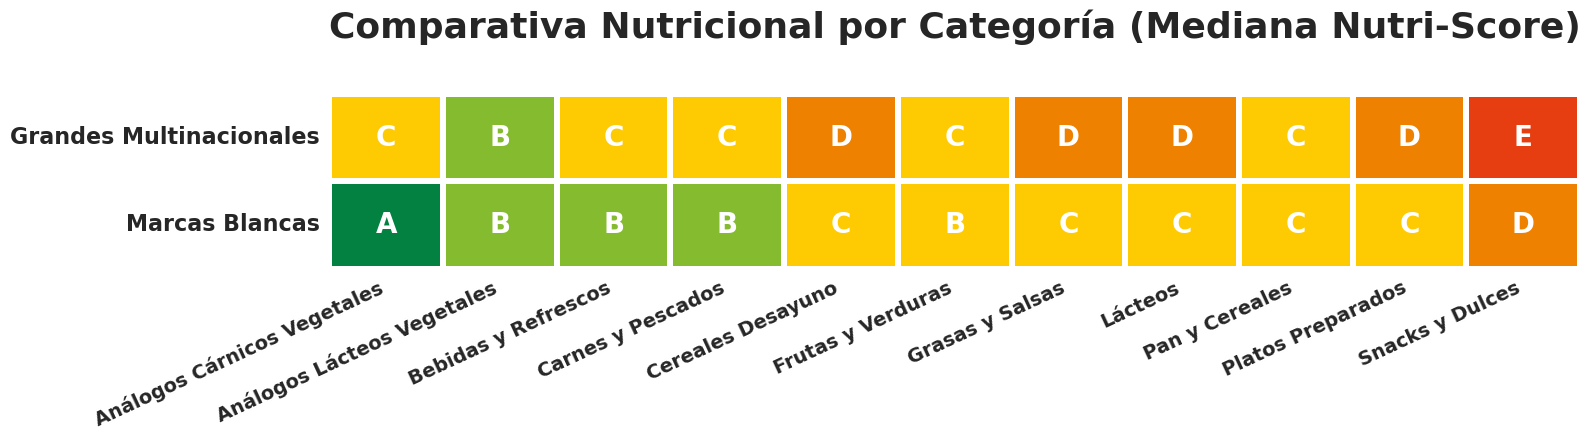

In [6]:
# --- HEATMAP NUTRI-SCORE ---
# 1. Diccionario de Traducción (Tu configuración)
traduccion_cat = {
    "beverage": "Bebidas y Refrescos",
    "dairy_eggs": "Lácteos",
    "meat_fish": "Carnes y Pescados",
    "fats_sauces": "Grasas y Salsas",
    "snacks_sweets": "Snacks y Dulces",
    "plant_based": "Frutas y Verduras",
    "plant_based_protein": "Análogos Cárnicos Vegetales",
    "plant_based_milks": "Análogos Lácteos Vegetales",
    "bread_and_grains": "Pan y Cereales",
    "ready_to_eat": "Platos Preparados",
    "breakfast_cereals": "Cereales Desayuno"
}

# 2. Configuración Nutri-Score
colores_ns = ['#038141', '#85BB2F', '#FECB02', '#EE8100', '#E63E11']
cmap_ns = ListedColormap(colores_ns)
map_nacional = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
map_reversa = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}

# 3. Preparación de Datos
df_heat = foods[
    (foods['nutriscore_grade'].notna()) & 
    (foods['nutriscore_grade'].str.lower().isin(['a', 'b', 'c', 'd', 'e'])) &
    (foods['grupo'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

# APLICAMOS LA TRADUCCIÓN AQUÍ
df_heat['category_es'] = df_heat['category_unified'].map(traduccion_cat)
df_heat['ns_num'] = df_heat['nutriscore_grade'].str.lower().map(map_nacional)

# 4. Matriz Pivotada (Usamos la columna traducida)
heatmap_data = df_heat.pivot_table(
    index='grupo', 
    columns='category_es', 
    values='ns_num', 
    aggfunc='median'
)

# Etiquetas internas (A, B, C...)
annot_labels = heatmap_data.round().replace(map_reversa).values

# 5. Visualización
plt.figure(figsize=(16, 4.5)) 
sns.set_style("white")

ax = sns.heatmap(
    heatmap_data, 
    annot=annot_labels,      
    fmt="",                  
    cmap=cmap_ns,         
    linewidths=3,            
    linecolor='white',
    cbar=False,              
    vmin=0.5, vmax=5.5,      
    annot_kws={"weight": "bold", "size": 20, "color": "white"}
)

# Estética y Fuentes
plt.title("Comparativa Nutricional por Categoría (Mediana Nutri-Score)", 
          fontsize=26, fontweight='bold', pad=40)

plt.xlabel("", fontsize=1)
plt.ylabel("", fontsize=1)

# Ajuste de etiquetas de los ejes
plt.xticks(rotation=25, ha='right', fontsize=14, fontweight='bold') 
plt.yticks(rotation=0, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/03_h03/3.3_Nutri-Score.png', bbox_inches='tight', dpi=300)
plt.show()

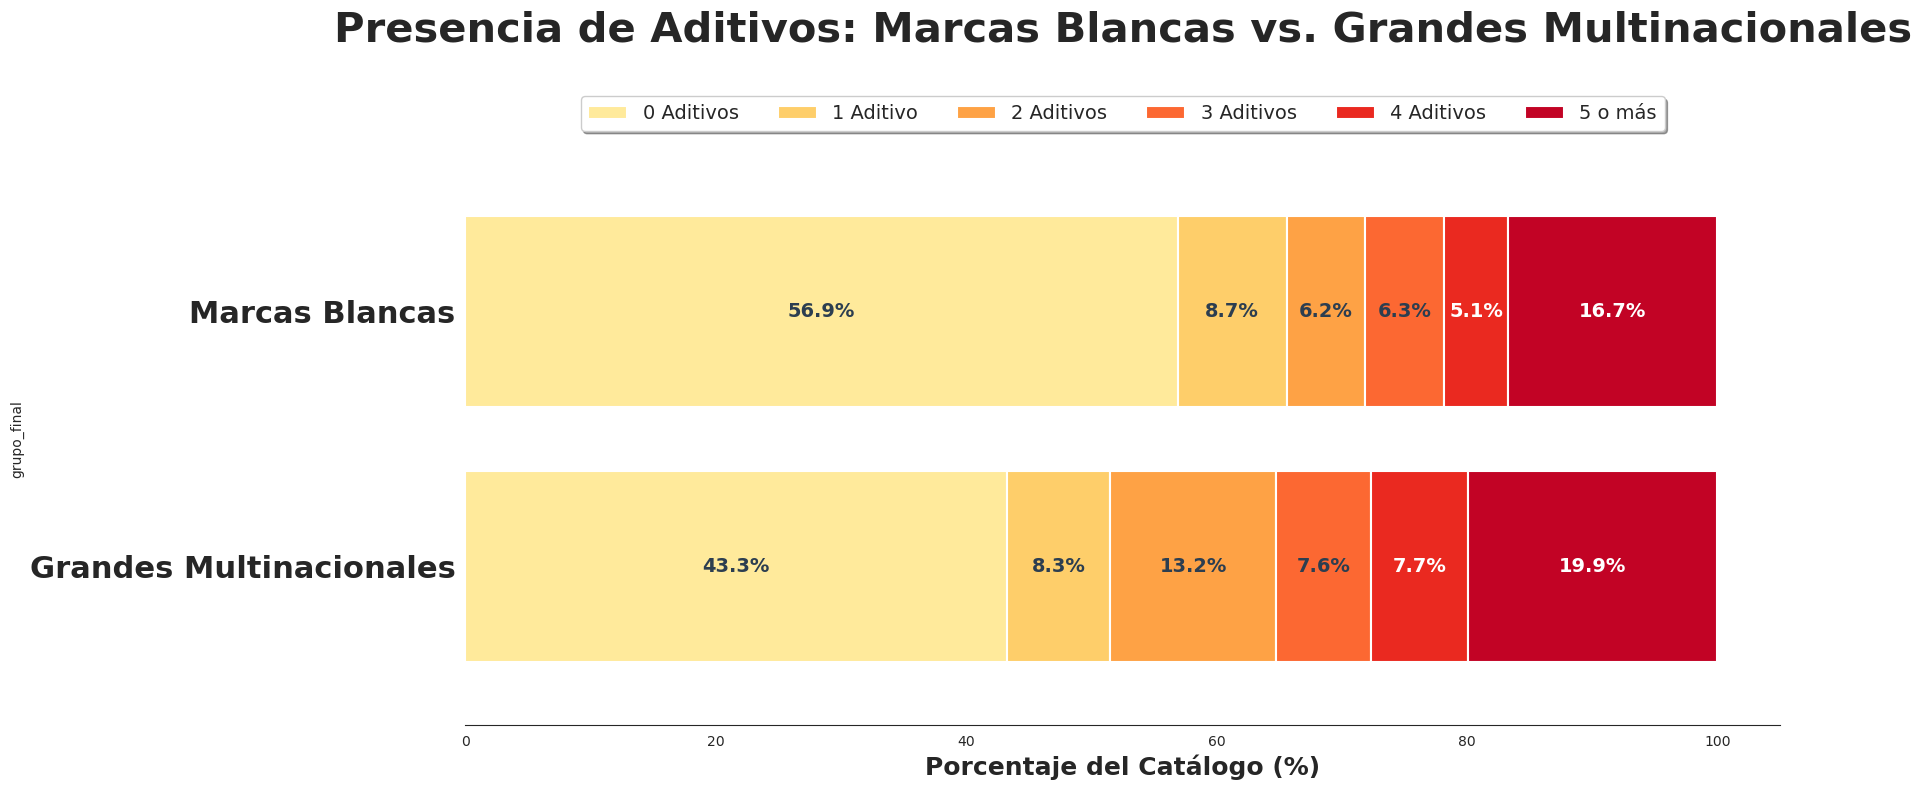

In [7]:
# --- COMPARATIVA DE ADITIVOS (CORREGIDA) ---

# 1. Clasificación
def clasificar_grupo_final(brand_str):
    brand_str = str(brand_str).lower()
    if any(mb in brand_str for mb in marcas_blancas):
        return 'Marcas Blancas'
    if any(multi in brand_str for multi in grandes_multinacionales):
        return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo_final'] = foods['brands'].apply(clasificar_grupo_final)

# 2. Agrupación de categorías
def agrupar_aditivos_label(c):
    if pd.isna(c) or c == 0: return '0 Aditivos'
    if c >= 5: return '5 o más'
    return f'{int(c)} Aditivo{"s" if c > 1 else ""}'

# 3. Filtrado y preparación (USANDO EL NOMBRE CORRECTO)
# He cambiado 'additives_n' por 'additive_count' que es el que tenías antes
df_plot = foods[foods['grupo_final'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()

# OJO AQUÍ: Asegúrate de usar el nombre exacto de tu columna
col_aditivos = 'additive_count' 
df_plot['additive_cat'] = df_plot[col_aditivos].apply(agrupar_aditivos_label)

cat_order = ['0 Aditivos', '1 Aditivo', '2 Aditivos', '3 Aditivos', '4 Aditivos', '5 o más']
counts = df_plot.groupby(['grupo_final', 'additive_cat']).size().unstack(fill_value=0)
pct_dist = counts.reindex(columns=cat_order, fill_value=0).div(counts.sum(axis=1), axis=0) * 100

# 4. Visualización (Igual que antes...)
plt.figure(figsize=(18, 8))
sns.set_style("white")
colors = sns.color_palette("YlOrRd", n_colors=len(cat_order))

ax = pct_dist.plot(kind='barh', stacked=True, color=colors, ax=plt.gca(),
                   width=0.75, edgecolor='white', linewidth=1.5, legend=False)

# Anotaciones
for i, (grupo, row_pct) in enumerate(pct_dist.iterrows()):
    cum_width = 0
    for j, cat in enumerate(cat_order):
        width = row_pct[cat]
        if width > 3.5:
            x_pos = cum_width + width / 2
            text_color = "white" if j >= 4 else "#2c3e50"
            ax.text(x_pos, i, f'{width:.1f}%', ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=14)
        cum_width += width

plt.title("Presencia de Aditivos: Marcas Blancas vs. Grandes Multinacionales", fontsize=30, fontweight='bold', pad=80)
plt.yticks(fontsize=22, fontweight='bold')
plt.xlabel("Porcentaje del Catálogo (%)", fontsize=18, fontweight='bold')
plt.legend(labels=cat_order, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=len(cat_order), frameon=True, shadow=True, fontsize=14)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('../images/03_h03/3.4_Presencia-Aditivos.png', bbox_inches='tight', dpi=300)
plt.show()

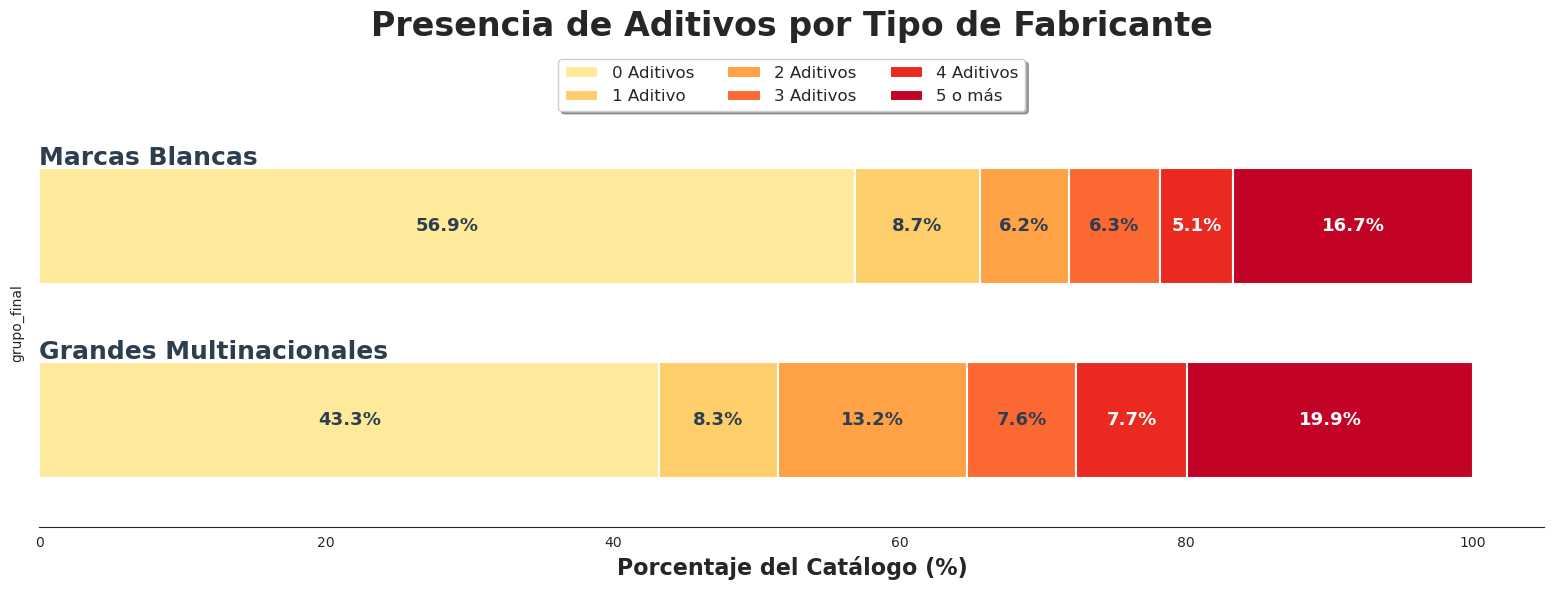

In [11]:
# --- COMPARATIVA DE ADITIVOS COMPACTA (Títulos sobre las barras) ---

# 1. Preparación de datos (Igual a tu lógica)
df_plot = foods[foods['grupo_final'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()
df_plot['additive_cat'] = df_plot['additive_count'].apply(agrupar_aditivos_label)

cat_order = ['0 Aditivos', '1 Aditivo', '2 Aditivos', '3 Aditivos', '4 Aditivos', '5 o más']
counts = df_plot.groupby(['grupo_final', 'additive_cat']).size().unstack(fill_value=0)
# Reordenamos las filas para que Marcas Blancas aparezca arriba si quieres (opcional)
counts = counts.reindex(['Grandes Multinacionales', 'Marcas Blancas']) 
pct_dist = counts.reindex(columns=cat_order, fill_value=0).div(counts.sum(axis=1), axis=0) * 100

# 2. Visualización
plt.figure(figsize=(16, 6)) # Reducimos altura para compactar
sns.set_style("white")
colors = sns.color_palette("YlOrRd", n_colors=len(cat_order))

ax = pct_dist.plot(kind='barh', stacked=True, color=colors, ax=plt.gca(),
                   width=0.6, edgecolor='white', linewidth=1.5, legend=False)

# 3. MOVER TÍTULOS ENCIMA DE LAS BARRAS
ax.set_yticklabels([]) # Borramos los nombres del eje Y original
for i, grupo in enumerate(pct_dist.index):
    # Escribimos el nombre del grupo justo encima de su barra
    ax.text(0, i + 0.35, grupo, fontsize=18, fontweight='bold', 
            ha='left', va='center', color='#2c3e50')

# 4. Anotaciones de porcentajes
for i, (grupo, row_pct) in enumerate(pct_dist.iterrows()):
    cum_width = 0
    for j, cat in enumerate(cat_order):
        width = row_pct[cat]
        if width > 3.5:
            x_pos = cum_width + width / 2
            text_color = "white" if j >= 4 else "#2c3e50"
            ax.text(x_pos, i, f'{width:.1f}%', ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=13)
        cum_width += width

# Ajustes de estilo para ahorrar espacio
plt.title("Presencia de Aditivos por Tipo de Fabricante", fontsize=24, fontweight='bold', pad=60)
plt.xlabel("Porcentaje del Catálogo (%)", fontsize=16, fontweight='bold')
plt.legend(labels=cat_order, bbox_to_anchor=(0.5, 1.0), loc='lower center', 
           ncol=3, frameon=True, shadow=True, fontsize=12) # Leyenda en 2 filas para no estirar horizontalmente

sns.despine(left=True, bottom=False)
plt.tight_layout()

# Este ajuste final es clave para que no quede hueco blanco a la izquierda
plt.subplots_adjust(left=0.05) 

plt.savefig('../images/03_h03/3.4_Presencia-Aditivos_Compacto.png', bbox_inches='tight', dpi=300)
plt.show()

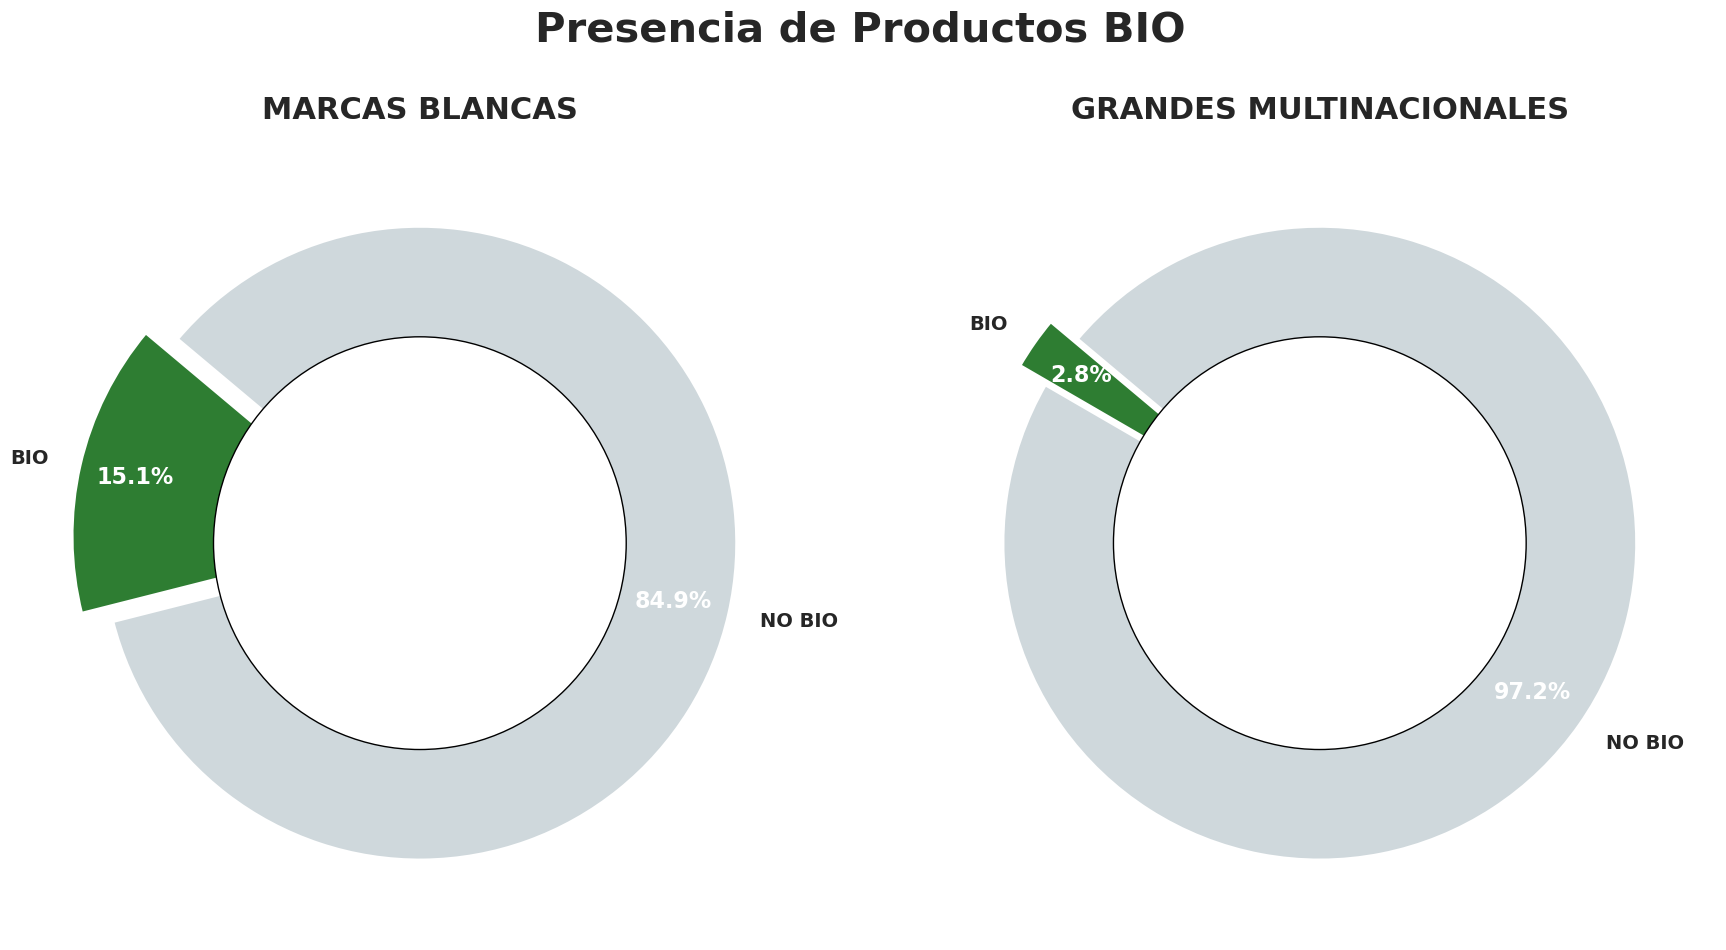

In [9]:
# --- COMPARATIVA DE PRODUCTOS BIO: MARCAS BLANCAS VS MULTINACIONALES ---

# 1. Clasificación (Mantenemos coherencia con tus listas)
def clasificar_grupo_bio(brand_str):
    brand_str = str(brand_str).lower()
    if any(mb in brand_str for mb in marcas_blancas):
        return 'Marcas Blancas'
    if any(multi in brand_str for multi in grandes_multinacionales):
        return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo_bio'] = foods['brands'].apply(clasificar_grupo_bio)

# 2. Preparación de datos
df_bio_plot = foods[foods['grupo_bio'].isin(['Marcas Blancas', 'Grandes Multinacionales'])].copy()

# 3. Configuración Visual
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
sns.set_style("white")

grupos = ['Marcas Blancas', 'Grandes Multinacionales']
colors_donut = ['#2E7D32', '#CFD8DC'] # Verde bosque para Bio, Gris azulado para No Bio

for i, grupo in enumerate(grupos):
    ax = axes[i]
    
    # Conteo de valores
    datos = df_bio_plot[df_bio_plot['grupo_bio'] == grupo]['is_bio'].value_counts()
    
    # Aseguramos que siempre existan ambas categorías para evitar errores visuales
    bio = datos.get(True, 0)
    no_bio = datos.get(False, 0)
    
    sizes = [bio, no_bio]
    labels = ['BIO', 'NO BIO']
    
    # Dibujamos el pastel
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors_donut,
        pctdistance=0.82, 
        explode=(0.1, 0), # Resaltamos la porción Bio
        wedgeprops={'edgecolor': 'white', 'linewidth': 3}
    )
    
    # Convertimos en Donut (Anillo)
    centre_circle = plt.Circle((0,0), 0.65, fc='white', edgecolor='black', linewidth=1)
    ax.add_artist(centre_circle)
    

    # Estética de etiquetas
    ax.set_title(f'{grupo.upper()}', fontsize=22, fontweight='bold', pad=20)
    
    for autotext in autotexts:
        autotext.set_fontsize(16)
        autotext.set_fontweight('bold')
        autotext.set_color('white') if autotext.get_text() != '0.0%' else autotext.set_color('none')
    
    for text in texts:
        text.set_fontsize(14)
        text.set_fontweight('bold')

# Título General imponente
plt.suptitle('Presencia de Productos BIO', 
             fontsize=30, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('../images/03_h03/3.5_Presencia-BIO.png', bbox_inches='tight', dpi=300)
plt.show()



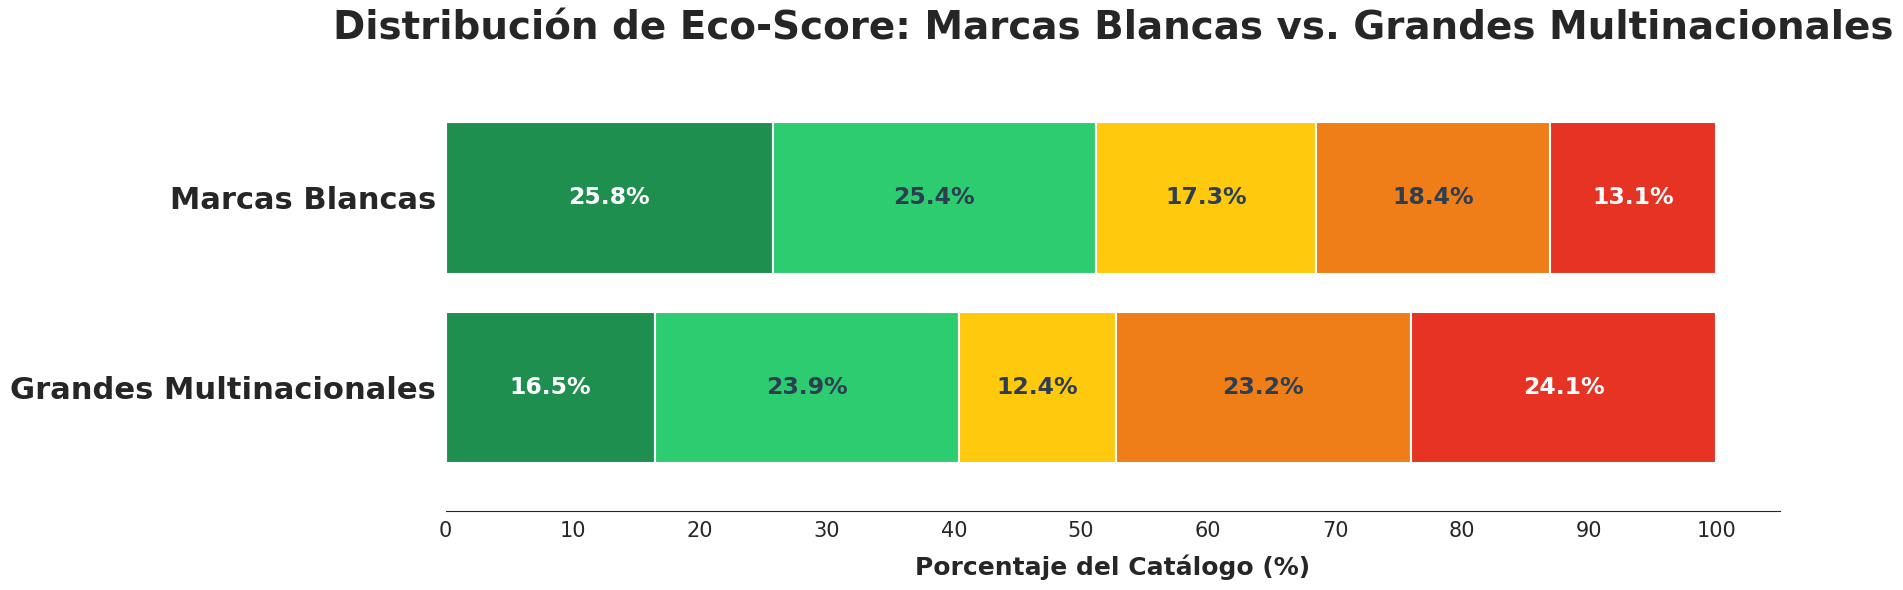

In [10]:
# --- COMPARATIVA DE ECO-SCORE ---

# 1. Clasificación y Filtrado (Misma lógica)
def clasificar_grupo_eco(brand_str):
    brand_str = str(brand_str).lower()
    if any(mb in brand_str for mb in marcas_blancas): return 'Marcas Blancas'
    if any(multi in brand_str for multi in grandes_multinacionales): return 'Grandes Multinacionales'
    return 'Otras'

foods['grupo_eco'] = foods['brands'].apply(clasificar_grupo_eco)

eco_order = ['a', 'b', 'c', 'd', 'e']
df_eco = foods[
    (foods['ecoscore_grade'].notna()) &
    (foods['ecoscore_grade'].str.lower().isin(eco_order)) &
    (foods['grupo_eco'].isin(['Marcas Blancas', 'Grandes Multinacionales']))
].copy()

eco_dist = df_eco.groupby(['grupo_eco', 'ecoscore_grade']).size().unstack(fill_value=0)
eco_pct = eco_dist.reindex(columns=eco_order, fill_value=0).div(eco_dist.sum(axis=1), axis=0) * 100

# 2. Visualización Compacta
plt.figure(figsize=(18, 6)) # Reducimos altura para compactar el visual
sns.set_style("white")

colors_eco = ['#1E8F4E', '#2ECC71', '#FFC90E', '#EF7D18', '#E63323']

ax = eco_pct.plot(
    kind='barh', 
    stacked=True, 
    color=colors_eco,
    ax=plt.gca(),
    width=0.8,      # Barras un poco más gruesas para llenar el espacio
    edgecolor='white',
    linewidth=1.5,
    legend=False    # ELIMINAMOS LEYENDA AQUÍ
)

# 3. Anotaciones de Porcentaje
for i, (grupo, row_pct) in enumerate(eco_pct.iterrows()):
    cum_width = 0
    for j, grade in enumerate(eco_order):
        width = row_pct[grade]
        if width > 3.5:
            x_pos = cum_width + width / 2
            text_color = "white" if j in [0, 4] else "#2c3e50"
            ax.text(x_pos, i, f'{width:.1f}%', ha='center', va='center', 
                    color=text_color, fontweight='bold', fontsize=17)
        cum_width += width

# 4. AJUSTE EXTREMO DE MÁRGENES Y TÍTULO
# Reducimos el pad a 25 para pegar el título al gráfico
plt.title("Distribución de Eco-Score: Marcas Blancas vs. Grandes Multinacionales", 
          fontsize=28, fontweight='bold', pad=25)

plt.xlabel("Porcentaje del Catálogo (%)", fontsize=18, fontweight='bold', labelpad=10)
plt.ylabel("", fontsize=1)
plt.xticks(range(0, 101, 10), fontsize=15)
plt.yticks(fontsize=22, fontweight='bold')

sns.despine(left=True, bottom=False)

plt.tight_layout() 
plt.savefig('../images/03_h03/3.6_Distribución-Eco-Score.png', bbox_inches='tight', dpi=300)
plt.show()